# Data Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *

## Importing Data

In [2]:
als = pd.read_csv("../data/ALS_Concat_Cleaned.csv", header = 0)
landsale = pd.read_csv("../data/landsale.csv", header = 0, na_values= "N.A.")
cleaned_lot_numbers = pd.read_csv("../data/lot_mappings.csv", header = 0)

In [3]:
als.tail()

,Unnamed: 0,Lot Number,Location,User,Site Area,Plot Ratio,Deposit (HK$ M),Estimated Earliest Site Available Date,Period,Rolled over
536,536,TKOTL 124,Tseung Kwan O Area 65C2,Residential R3,1.9900 ha,NaN,NaN,February 2013,2012/2013,0
537,537,YLTL 528,"Tak Yip Street, Tung Tau, Yuen Long",Residential R2,0.4400 ha,NaN,NaN,February 2013,2012/2013,0
538,538,Lot 1003 in DD 40,Junction of Shun Lung Street and Shun Cheong S...,Residential R2,0.3344 ha,NaN,NaN,March 2013,2012/2013,0
539,539,Lot 1004 in DD 40,"Che Ping Street, Sha Tau Kok",Residential R2,0.0458 ha,NaN,NaN,March 2013,2012/2013,0
540,540,KIL 11235,"Junction of Argyle Street and Canton Road, Kow...",Commercial / Office / Hotel,0.1240 ha,NaN,NaN,March 2013,2012/2013,0


In [4]:
landsale.tail()

,financial_year,award_date,sale_type,lot_number,location,use,use_category_normalized,site_area_sqm,premium_hkd_m,cancelled,...,gfa_check,min_flat_count,flat_size_restriction,flat_req_special,flat_req_source,flat_req_confidence,consent_development,consent_developer,consent_status,consent_date
1002,2025-2026,16/02/2026,tender,SHAU KEI WAN INLAND LOT NO. 860,"SHAU KEI WAN MAIN STREET EAST, HONG KONG",RESIDENTIAL,residential,1349.2,1383.899,NaN,...,NaN,NaN,NaN,NaN,https://www.legco.gov.hk/research-publications...,inferred-N,NaN,NaN,No consent,NaN
1003,2025-2026,24/02/2026,tender,TSING YI TOWN LOT NO. 203,"183 TSING YI ROAD ELECTRIC WEST, TSING YI, NEW...",VEHICLE STATION,transport_parking,1973.9,12.450,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No consent,NaN
1004,2025-2026,2/3/2026,tender,LOT NO. 953 IN DEMARCATION DISTRICT NO. 89,"SHA LING ROAD, SANDY RIDGE, NEW DATA TERRITORI...",HIGH-TIER CENTRE,data_centre,116365.0,581.000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No consent,NaN
1005,2026-2027,12/5/2026,tender,TSEUNG KWAN O TOWN LOT NO. 137,"PO HONG ROAD, ELECTRIC TSEUNG KWAN O, CHARGING...",VEHICLE STATION,transport_parking,2640.0,36.386,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No consent,NaN
1006,2026-2027,19/05/2026,tender,TUNG CHUNG TOWN LOT NO. 54,"AREA 106A, TUNG CHUNG, NEW TERRITORIES P. 1",RESIDENTIAL,residential,14152.0,1627.000,NaN,...,NaN,NaN,NaN,NaN,https://www.legco.gov.hk/research-publications...,inferred-N,NaN,NaN,No consent,NaN


In [5]:
cleaned_lot_numbers.tail()

,Original,Clean,Source
1102,YLTL 518,YLTL518,ALS_Concat_Cleaned.csv & landsale.csv
1103,YLTL 523,YLTL523,landsale.csv
1104,YLTL 528,YLTL528,ALS_Concat_Cleaned.csv
1105,YUEN LONG TOWN LOT NO. 528,YLTL528,landsale.csv
1106,YUEN LONG TOWN LOT NO. 532,YLTL532,landsale.csv


## Data Cleaning

### Landsale Data

In [6]:
print(landsale.columns, '\n')
print(landsale.shape)

Index(['financial_year', 'award_date', 'sale_type', 'lot_number', 'location',
       'use', 'use_category_normalized', 'site_area_sqm', 'premium_hkd_m',
       'cancelled', 'parse_confidence', 'development_english_name',
       'development_address_english', 'csdi_lot_number', 'num_bids',
       'successful_tenderer', 'other_bidders', 'latitude', 'longitude',
       'sale_regime', 'sale_regime_source', 'parent_developer', 'max_gfa',
       'gfa_unit', 'accommodation_value', 'av_unit', 'premium_crosscheck_ok',
       'source_url', 'note', 'buyer_normalized', 'buyer_type', 'winner_source',
       'maxgfa_source', 'devm_name_source', 'gfa_check', 'min_flat_count',
       'flat_size_restriction', 'flat_req_special', 'flat_req_source',
       'flat_req_confidence', 'consent_development', 'consent_developer',
       'consent_status', 'consent_date'],
      dtype='str') 

(1007, 44)


#### Obtain Useful Columns

In [7]:
cols = ['premium_hkd_m', 'num_bids', 'successful_tenderer', 'buyer_normalized', 'buyer_type', 'use_category_normalized', 'latitude', 'longitude',
        'parent_developer', 'award_date', 'sale_regime', 'site_area_sqm', 'lot_number', 'financial_year', 'location','max_gfa', 'accommodation_value']

ls = landsale[cols].copy()
ls.head()

,premium_hkd_m,num_bids,successful_tenderer,buyer_normalized,buyer_type,use_category_normalized,latitude,longitude,parent_developer,award_date,sale_regime,site_area_sqm,lot_number,financial_year,location,max_gfa,accommodation_value
0,12.10,NaN,NaN,NaN,NaN,industrial,22.382991,114.205675,NaN,18/04/1985,govt-led,4915.0,STTL 275,1985-1986,SHATIN AREA 14B,NaN,NaN
1,701.28,NaN,NaN,NaN,NaN,commercial_residential_mixed,22.277606,114.165861,NaN,18/04/1985,govt-led,10690.0,IL 8571,1985-1986,QUEENSWAY (V.B.PACK NO.1),NaN,NaN
2,45.50,NaN,NaN,NaN,NaN,residential,22.392917,114.187430,NaN,18/04/1985,govt-led,11710.0,STTL 194,1985-1986,SHATIN AREA 41A,NaN,NaN
3,27.00,NaN,NaN,NaN,NaN,residential,22.391337,114.188440,NaN,18/04/1985,govt-led,9515.0,STTL 225,1985-1986,SHATIN AREA 41A,NaN,NaN
4,1.80,NaN,NaN,NaN,NaN,residential,22.394886,114.188673,NaN,18/04/1985,govt-led,960.0,STTL 252,1985-1986,SHATIN AREA 41A,NaN,NaN


#### Check N.A. Counts

In [8]:
ls['award_date'] = pd.to_datetime(ls['award_date'], format= 'mixed')
pd.DataFrame(ls.isna().sum()).sort_values(0, ascending=False)

,0
accommodation_value,766
max_gfa,766
parent_developer,748
buyer_normalized,730
buyer_type,730
num_bids,668
successful_tenderer,494
latitude,151
longitude,151
premium_hkd_m,43


In [9]:
pd.DataFrame(ls.describe())

,premium_hkd_m,latitude,longitude,award_date,site_area_sqm,max_gfa,accommodation_value
count,964.000000,856.000000,856.000000,1007,985.000000,2.410000e+02,241.000000
mean,1295.677259,22.359780,114.137020,2001-10-17 22:22:45.640516,8925.497970,9.313737e+04,9365.518672
min,0.100000,22.200817,113.932435,1985-04-18 00:00:00,65.000000,5.752000e+02,216.000000
25%,45.000000,22.299820,114.074013,1990-09-25 00:00:00,1591.000000,1.346800e+04,3932.000000
50%,237.530000,22.364970,114.162643,1998-05-22 00:00:00,4171.000000,3.600000e+04,6530.000000
75%,1052.282500,22.419772,114.204313,2013-07-10 00:00:00,10570.000000,7.820000e+04,12003.000000
max,50800.000000,22.544040,114.298097,2026-12-05 00:00:00,650242.000000,1.438200e+06,62354.000000
std,3319.115099,0.077893,0.089910,NaN,24963.890727,1.982483e+05,8732.213336


#### Calculating the proportion of missing values for these columns per financial year

In [10]:
ls.groupby('financial_year')[['num_bids', 'buyer_normalized', 'buyer_type', 'parent_developer']].apply(lambda x: x.isna().mean()).reset_index()

,financial_year,num_bids,buyer_normalized,buyer_type,parent_developer
0,1985-1986,1.000000,1.000000,1.000000,1.000000
1,1986-1987,1.000000,1.000000,1.000000,1.000000
2,1987-1988,1.000000,1.000000,1.000000,1.000000
3,1988-1989,1.000000,1.000000,1.000000,1.000000
4,1989-1990,1.000000,1.000000,1.000000,1.000000
5,1990-1991,1.000000,1.000000,1.000000,1.000000
6,1991-1992,1.000000,1.000000,1.000000,1.000000
7,1992-1993,1.000000,1.000000,1.000000,1.000000
8,1993-1994,1.000000,1.000000,1.000000,1.000000
9,1994-1995,1.000000,1.000000,1.000000,1.000000


There is no bidding information in 2002-2003

#### Restrict the Data to period (1999 - 2026)

In [11]:
period = (landsale['financial_year']
          .drop_duplicates(keep="first")
          .sort_values(ascending=True)
          .to_list())

period = pd.Categorical(period, ordered=True)

ls = ls[ls['financial_year'] >= '1999-2000']

missing_table = ls.isna().agg(['sum', 'mean']).T.rename(columns={'sum': 'Count of Missing Values', 'mean': 'Proportion (493 obs.)'}).reset_index(names="Column")
missing_table['Proportion (493 obs.)'] = missing_table['Proportion (493 obs.)'] * 100
missing_table.sort_values('Proportion (493 obs.)', ascending=False).reset_index(drop=True)

,Column,Count of Missing Values,Proportion (493 obs.)
0,accommodation_value,252.0,51.115619
1,max_gfa,252.0,51.115619
2,parent_developer,234.0,47.464503
3,buyer_normalized,216.0,43.813387
4,buyer_type,216.0,43.813387
5,num_bids,158.0,32.048682
6,latitude,54.0,10.953347
7,longitude,54.0,10.953347
8,premium_hkd_m,43.0,8.722110
9,sale_regime,27.0,5.476673


#### Merge with Cleaned Lot Numbers for a Unified Primary Key

In [12]:
ls = (ls.
      merge(cleaned_lot_numbers, left_on="lot_number", right_on="Original", how = "left")
      .drop(columns=['Original', 'Source'])
      .rename(columns={'Clean': 'lot_number_normalized'}))
ls['lot_number_normalized'].isna().sum()

np.int64(0)

### ALS Data

#### Add in Normalised Lot Number and Drop Unnecessary Columns

In [13]:
als = als.drop(columns=["Unnamed: 0"])
als = (als
       .merge(cleaned_lot_numbers, left_on = "Lot Number", right_on = "Original", how = "left")
       .drop(columns=['Original', 'Source'])
       .rename(columns={'Clean': 'lot_number_normalized'}))
als['lot_number_normalized'].isna().sum()

np.int64(0)

#### Add Site Area in Square Meters

In [14]:
# ALS's own Site Area column is text like '1.9900 ha'; parse it into a
# numeric square-meter column (kept separate from landsale's site_area_sqm,
# which is what the premium-per-area metric below actually uses).
als['als_site_area_sqm'] = als['Site Area'].str.replace(' ha', '', regex=False).astype(float) * 10000
als[['Site Area', 'als_site_area_sqm']].head()

,Site Area,als_site_area_sqm
0,0.8895 ha,8895.0
1,0.1925 ha,1925.0
2,0.1050 ha,1050.0
3,1.0700 ha,10700.0
4,0.2130 ha,2130.0


#### Clean Up the Earliest Available Date Columns

In [15]:
als['Estimated Earliest Site Available Date'] = als['Estimated Earliest Site Available Date'].replace("Now", np.nan)
als['Estimated Earliest Site Available Date'] = als.groupby("Lot Number")['Estimated Earliest Site Available Date'].transform("first")
als['Estimated Earliest Site Available Date'] = pd.to_datetime(als['Estimated Earliest Site Available Date'], format= "mixed").dt.strftime("%b-%Y")

#### Obtain a New DataFrame of Unique Listing

In [16]:
als2 = als.drop_duplicates(subset=['lot_number_normalized'], keep="first").copy()
ls['in_als'] = np.where(ls['lot_number_normalized'].isin(als2['lot_number_normalized']), 1, 0)
total = ls.merge(als2, on= "lot_number_normalized", how = "left")

In [17]:
matched_lots = set(
    ls.loc[
        ls['lot_number_normalized'].isin(als2['lot_number_normalized']),
        'lot_number_normalized'
    ]
)
als_unmatched = als2[
    ~als2['lot_number_normalized'].isin(matched_lots)
]
ls_unmatched = total[total['in_als'] == 0].copy()

merge_results = pd.DataFrame({
    'Total Matches': total['in_als'].sum(),
    'ALS Unmatch Count': als_unmatched.shape[0],
    'Land Sale Unmatched Count': ls_unmatched.shape[0], 
    'Total Unique ALS Lot Numbers': als2.shape[0],
    'Total Land Sale Records in Period': ls.shape[0], 
}, index = [0]).T.reset_index()

merge_results.columns = ['Index', 'Count']
merge_results

,Index,Count
0,Total Matches,152
1,ALS Unmatch Count,37
2,Land Sale Unmatched Count,341
3,Total Unique ALS Lot Numbers,189
4,Total Land Sale Records in Period,493


## DataFrame Diagnostics

### Total DataFrame

#### Checking Land Use Case

In [18]:
pd.DataFrame(total['use_category_normalized'].value_counts(sort=True)).reset_index()

,use_category_normalized,count
0,residential,306
1,petrol_or_ev,83
2,commercial,39
3,industrial,12
4,commercial_residential_mixed,9
5,transport_parking,9
6,hotel_mixed,8
7,hotel,7
8,telecom,6
9,logistics,5


#### Cross Tabulate Land Use against ALS Status

In [19]:
pd.crosstab(ls['use_category_normalized'], ls['in_als'], margins=True).reset_index()

in_als,use_category_normalized,0,1,All
0,commercial,25,14,39
1,commercial_residential_mixed,4,5,9
2,data_centre,3,0,3
3,hotel,2,5,7
4,hotel_mixed,6,2,8
5,industrial,7,5,12
6,institutional_public,3,0,3
7,logistics,5,0,5
8,petrol_or_ev,83,0,83
9,residential,187,119,306


#### Keep only Residential and Residential/Residential + Commercial Properties

In [20]:
filtered = total[total['use_category_normalized'].str.contains('residential')].copy()

## Exploratory Data Analysis

### ALS DataFrame

In [21]:
als['Period'].unique()

<StringArray>
['1999/2000', '2001/2002', '2002/2003', '2004/2005', '2005/2006', '2006/2007',
 '2007/2008', '2008/2009', '2009/2010', '2010/2011', '2011/2012', '2012/2013']
Length: 12, dtype: str

In [22]:
als3 = als[['Lot Number', 'Location', 'User', 'Site Area', 'Period', 'Rolled over']].copy()
als3 = als3[als3['User'].str.contains("Residential")]
als3['Site Area'] = als3['Site Area'].str.replace("ha", "").astype(float)

als3.head()

,Lot Number,Location,User,Site Area,Period,Rolled over
0,FSSTL 177,"Area 19, Sha Tau Kok Road, Fanling",Commercial / Residential,0.8895,1999/2000,0
1,RBL 1143,Adjacent to 16 & 18 South Bay Road,Residential R3,0.1925,1999/2000,0
2,Lot 673 in DD Peng Chau,"Site No 2, Tung Wan, Peng Chau",Residential R3,0.1050,1999/2000,0
3,Lot 1848 in DD Cheung Chau,"Shui Hang, Cheung Chau",Residential R4,1.0700,1999/2000,0
4,Lot 1847 in DD Cheung Chau,"Site 1, Sai Wan, Cheung Chau",Residential R4,0.2130,1999/2000,0


In [23]:
agg_res = als3.groupby(['Period', 'Rolled over'])[['Site Area']].sum().reset_index()
print(pd.DataFrame(agg_res['Period'].unique()))
agg_res.head()

            0
0   1999/2000
1   2001/2002
2   2002/2003
3   2004/2005
4   2005/2006
5   2006/2007
6   2007/2008
7   2008/2009
8   2009/2010
9   2010/2011
10  2011/2012
11  2012/2013


,Period,Rolled over,Site Area
0,1999/2000,0,22.2128
1,2001/2002,0,16.9960
2,2001/2002,1,3.1360
3,2002/2003,0,12.6382
4,2002/2003,1,13.7785


##### Why did Total Site Area Dip Dramatically in 2010?

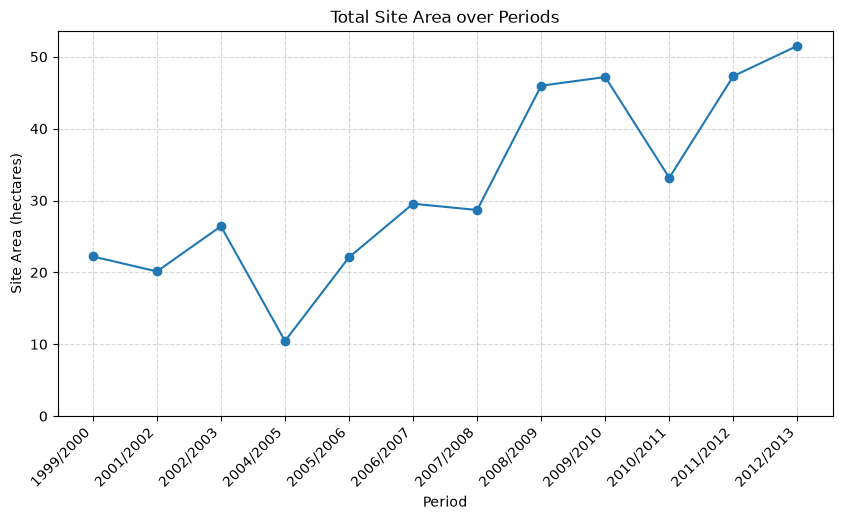

In [24]:
new_agg = als3.groupby("Period")[['Site Area']].sum().reset_index()

fig, ax = plt.subplots(figsize = (10,5))

ax.plot(new_agg['Period'], new_agg['Site Area'], marker = "o", zorder = 3)
ax.set(xlabel = "Period", ylabel = "Site Area (hectares)", title = "Total Site Area over Periods")

plt.ylim(bottom=0)
plt.xticks(rotation = 45, ha = "right")
plt.grid(linestyle = "--", alpha = 0.5)
plt.show()

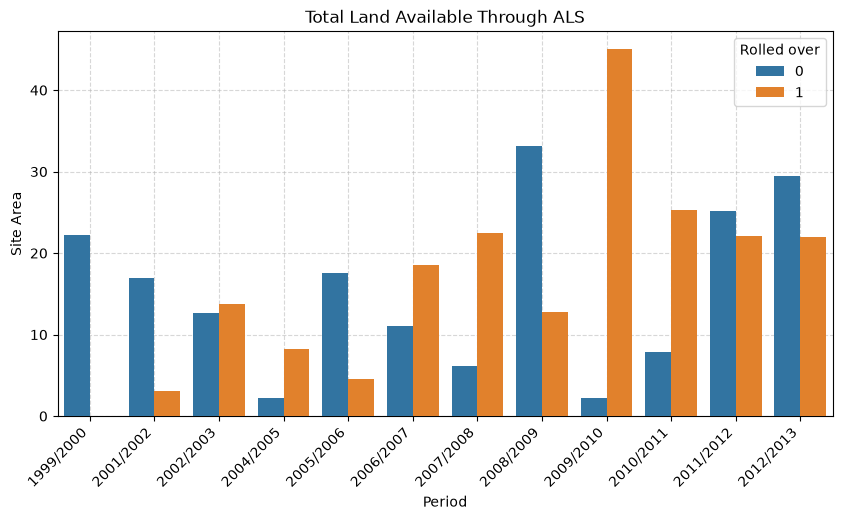

In [25]:
fig, ax = plt.subplots(figsize = (10,5))

sns.barplot(agg_res, x="Period", y="Site Area", hue= "Rolled over",
            ax = ax, zorder = 3)

plt.title("Total Land Available Through ALS")
plt.grid(linestyle = "--", alpha = 0.5)
plt.xticks(rotation = 45, ha = "right")
plt.show()

##### How much land did the government take out of ALS and Sell in Auctions? 

In [26]:
total['Site Area'] = total['Site Area'].str.replace("ha", '').astype(float)
govt_led_als = total[(total['sale_regime'] == 'govt-led') & (total['in_als'] == 1)].copy()
print('Sites pulled from ALS and sold govt-led:', govt_led_als.shape[0])
print('Total land area (sqm):', govt_led_als['site_area_sqm'].sum())
print('Total land area (ha):', govt_led_als['site_area_sqm'].sum() / 10000)
govt_led_als.head()

Sites pulled from ALS and sold govt-led: 88
Total land area (sqm): 877794.4
Total land area (ha): 87.77944000000001


,premium_hkd_m,num_bids,successful_tenderer,buyer_normalized,buyer_type,use_category_normalized,latitude,longitude,parent_developer,award_date,...,Lot Number,Location,User,Site Area,Plot Ratio,Deposit (HK$ M),Estimated Earliest Site Available Date,Period,Rolled over,als_site_area_sqm
62,660.0,NaN,Landyork Investment Limited,NaN,NaN,residential,22.401044,114.194384,NaN,2002-04-15,...,STTL 526,"Ex-Pak Tak Yuen, Lok Kwai Path, Sha Tin",Residential R3,2.0650,1.5,50.0,Aug-2001,2001/2002,0.0,20650.0
144,10900.0,NaN,Polarland Limited,Sun Hung Kai Properties,local_major,residential,22.311823,114.181960,Sun Hung Kai Properties,2010-08-06,...,KIL 11175,"J/O Fat Kwong Street and Chung Hau Streeet, Ho...",Residential R1,1.6291,NaN,NaN,Mar-2007,2006/2007,0.0,16291.0
147,10400.0,NaN,Market Prospect Limited,Wheelock/Wharf + Nan Fung,consortium,residential,22.263681,114.180464,The Wharf (Holdings) / Nan Fung,2010-07-28,...,IL 9007,103 Mt. Nicholson Road,Residential R3,2.3290,NaN,NaN,Jan-2006,2005/2006,0.0,23290.0
151,459.0,NaN,Supreme Rich Investment Limited,Sun Hung Kai Properties,local_major,residential,22.499491,114.140770,Sun Hung Kai Properties,2010-09-29,...,FSSTL 202,"Area 21, Fan Leng Lau Road",Residential R1,0.2560,NaN,NaN,Apr-2007,2007/2008,0.0,2560.0
153,816.0,7,The Hongkong and Shanghai Banking Corporation ...,HSBC,other,commercial,22.389492,114.208337,HSBC,2010-10-20,...,STTL 433,"Junction of On Kwan Street and On Yiu Street, ...",Business (incl Public Storey Carpark),0.8530,NaN,NaN,Sep-2006,2006/2007,0.0,8530.0


In [27]:
gla_agg = govt_led_als.groupby("financial_year")[['Site Area']].sum().reset_index()
gla_agg = pd.merge(pd.DataFrame(total['financial_year'].unique()), gla_agg, left_on = 0, right_on="financial_year", how = "left")
gla_agg = gla_agg.drop(columns={'financial_year'}).rename(columns={0:'financial_year'}).fillna(0)
gla_agg

,financial_year,Site Area
0,1999-2000,0.0000
1,2000-2001,0.0000
2,2001-2002,0.0000
3,2002-2003,2.0650
4,2003-2004,0.0000
5,2004-2005,0.0000
6,2005-2006,0.0000
7,2006-2007,0.0000
8,2007-2008,0.0000
9,2008-2009,0.0000


In [28]:
extracted = pd.DataFrame(govt_led_als['Period'].value_counts(sort=True)).reset_index()
new_site_count = als2.groupby("Period")[['Site Area']].count().reset_index().rename(columns={'Site Area': 'Count'})
comp = new_site_count.merge(extracted, on = "Period", how= "left")
comp['Ratio (%)'] = (comp['count']/comp['Count']) * 100
comp = comp.rename(columns={'Count': 'Total Listings', 'count': 'Extracted'}).fillna(0) 
comp

,Period,Total Listings,Extracted,Ratio (%)
0,1999/2000,32,7.0,21.875000
1,2001/2002,27,6.0,22.222222
2,2002/2003,11,0.0,0.000000
3,2004/2005,7,2.0,28.571429
4,2005/2006,16,7.0,43.750000
5,2006/2007,12,4.0,33.333333
6,2007/2008,5,2.0,40.000000
7,2008/2009,23,13.0,56.521739
8,2009/2010,3,3.0,100.000000
9,2010/2011,11,9.0,81.818182


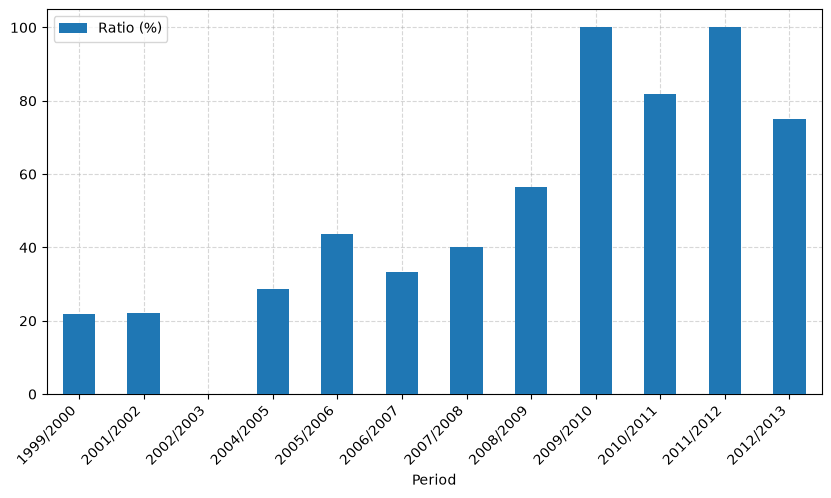

In [29]:
comp.plot(kind='bar', x="Period", y="Ratio (%)", zorder = 3, figsize = (10,5))

plt.grid(linestyle = "--", alpha = 0.5, zorder = 1)
plt.xticks(rotation = 45, ha = "right")
plt.show()

Find the average date where the properties are given out

In [30]:
cols = ['financial_year', 'award_date', 'Period','use_category_normalized', 'premium_hkd_m', 'als_site_area_sqm','site_area_sqm', 'sale_regime']
govt_led_als_2 = govt_led_als[cols].copy().reset_index(drop= True)
govt_led_als_2.head()

,financial_year,award_date,Period,use_category_normalized,premium_hkd_m,als_site_area_sqm,site_area_sqm,sale_regime
0,2002-2003,2002-04-15,2001/2002,residential,660.0,20650.0,19300.0,govt-led
1,2010-2011,2010-08-06,2006/2007,residential,10900.0,16291.0,16151.0,govt-led
2,2010-2011,2010-07-28,2005/2006,residential,10400.0,23290.0,23312.0,govt-led
3,2010-2011,2010-09-29,2007/2008,residential,459.0,2560.0,2560.0,govt-led
4,2010-2011,2010-10-20,2006/2007,commercial,816.0,8530.0,8533.0,govt-led


In [31]:
govt_led_als_2['year_in_als'] = govt_led_als_2['Period'].str[:4].astype(int)
govt_led_als_2['year_sold'] = govt_led_als_2['financial_year'].str[:4].astype(int)
govt_led_als_2['lag_years'] = govt_led_als_2['year_sold'] - govt_led_als_2['year_in_als']
govt_led_als_2.groupby("Period")[['lag_years']].agg(['mean', 'median']).reset_index()

Period  lag_years       
                    mean median
0   1999/2000  13.285714   12.0
1   2001/2002   9.333333   10.5
2   2004/2005   7.500000    7.5
3   2005/2006   8.285714    7.0
4   2006/2007   4.500000    4.5
5   2007/2008   4.500000    4.5
6   2008/2009   3.538462    3.0
7   2009/2010   2.666667    2.0
8   2010/2011   1.555556    1.0
9   2011/2012   0.857143    1.0
10  2012/2013   0.952381    1.0

### Filtered DataFrame

#### Variable: Premium in HKD Millions 

In [32]:
pd.DataFrame(filtered['premium_hkd_m'].describe())

,premium_hkd_m
count,306.000000
mean,2426.095446
std,3360.258826
min,4.500000
25%,312.500000
50%,1204.090900
75%,3036.000000
max,25161.000000


##### Observations: 
1. Mean is much larger than median, about 2x 
2. High Potential of Outliers

In [33]:
print('Number of NA values in Variable: ', filtered['premium_hkd_m'].isna().sum(), '\n',
      'Proportion of Missing: ', filtered['premium_hkd_m'].isna().sum()/filtered.shape[0])

filtered.groupby('financial_year')[['premium_hkd_m']].apply(lambda x: x.isna().mean()).reset_index().rename(columns={'premium_hkd_m': 'proportion of missing values'})

Number of NA values in Variable:  9 
 Proportion of Missing:  0.02857142857142857


,financial_year,proportion of missing values
0,1999-2000,0.000000
1,2000-2001,0.000000
2,2001-2002,0.000000
3,2002-2003,0.000000
4,2004-2005,0.000000
5,2005-2006,0.000000
6,2006-2007,0.000000
7,2007-2008,0.000000
8,2008-2009,0.000000
9,2009-2010,0.000000


In [34]:
total[total['financial_year'] == '2003-2004'][['use_category_normalized']].copy()

,use_category_normalized
68,commercial
69,special_use_other
70,petrol_or_ev
71,petrol_or_ev
72,petrol_or_ev
73,petrol_or_ev
74,petrol_or_ev
75,petrol_or_ev
76,petrol_or_ev
77,petrol_or_ev


Note: There are no residential sales in 2003-2004

##### Observation: 
+ Low number of missing values, randomly distributed

In [35]:
res = filtered.groupby('financial_year')[['premium_hkd_m']].describe().reset_index()
res.columns = res.columns.droplevel(0)
res = res.rename(columns={'': 'financial_year'})  

new_row_data = {col: 0 if col != 'financial_year' else '2003-2004' for col in res.columns}
new_row = pd.DataFrame([new_row_data])
res = pd.concat([res, new_row], ignore_index=True)
res = res.sort_values(by='financial_year').reset_index(drop=True)

res

,financial_year,count,mean,std,min,25%,50%,75%,max
0,1999-2000,22.0,506.290909,678.535709,4.500000,156.5000,357.500000,545.000000,3240.000000
1,2000-2001,18.0,797.282778,909.008662,21.000000,112.6000,416.000000,861.250000,2580.000000
2,2001-2002,10.0,93.800000,78.514047,23.500000,39.1250,53.000000,138.500000,264.000000
3,2002-2003,7.0,526.000000,534.807130,100.000000,201.0000,310.000000,615.000000,1640.000000
4,2003-2004,0.0,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000
5,2004-2005,5.0,3617.000000,3589.894845,865.000000,1010.0000,2090.000000,4700.000000,9420.000000
6,2005-2006,3.0,3383.333333,768.461667,2730.000000,2960.0000,3190.000000,3710.000000,4230.000000
7,2006-2007,9.0,1482.222222,1358.694551,30.500000,96.5000,1800.000000,2110.000000,3500.000000
8,2007-2008,8.0,3252.750000,2177.149627,482.000000,915.0000,3990.000000,4802.500000,5710.000000
9,2008-2009,1.0,16.500000,NaN,16.500000,16.5000,16.500000,16.500000,16.500000


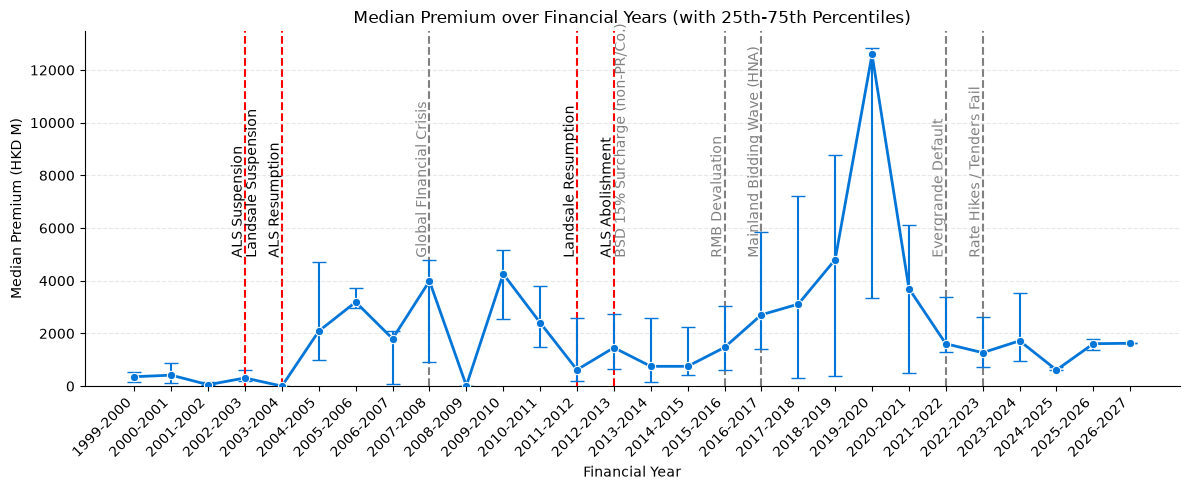

In [36]:
fig, ax = plt.subplots(figsize = (12,5))

sns.lineplot(data=res, x='financial_year', y='50%', marker='o', color='#0275d8', linewidth=2, ax= ax, zorder = 3)
plt.errorbar(
    x=res['financial_year'], 
    y=res['50%'], 
    yerr=[res['50%'] - res['25%'], res['75%'] - res['50%']], 
    fmt='none', color='#0275d8', capsize=5, elinewidth=1.5
    )
plt.title("Median Premium over Financial Years (with 25th-75th Percentiles)")
plt.xlabel("Financial Year")
plt.ylabel("Median Premium (HKD M)")
plt.xticks(rotation=45, ha = 'right')
plt.grid(axis="y", linestyle = "--", zorder = 0, alpha = 0.3)
plt.ylim(bottom=0)
sns.despine()

ax.axvline(x = "2002-2003", linestyle = "--", color = "red")
ax.annotate("ALS Suspension", xy= ("2002-2003", 5000), ha = 'right', rotation = 90, zorder = 1)
ax.annotate("Landsale Suspension", xy= ("2002-2003", 5000), ha = 'left', rotation = 90)

ax.axvline(x = "2003-2004", linestyle = "--", color = "red", zorder = 1)
ax.annotate("ALS Resumption", xy= ("2003-2004", 5000), ha = 'right', rotation = 90)

ax.axvline(x = "2011-2012", linestyle = "--", color = "red", zorder = 1)
ax.annotate("Landsale Resumption", xy= ("2011-2012", 5000), ha = 'right', rotation = 90)

ax.axvline(x = "2012-2013", linestyle = "--", color = "red", zorder = 1)
ax.annotate("ALS Abolishment", xy= ("2012-2013", 5000), ha = 'right', rotation = 90)

ax.axvline(x = "2007-2008", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("Global FInancial Crisis", xy= ("2007-2008", 5000), ha = 'right', rotation = 90, color = 'grey')

ax.annotate("BSD 15% Surcharge (non-PR/Co.)", xy= ("2012-2013", 5000), ha = 'left', rotation = 90, color = 'gray')

ax.axvline(x = "2015-2016", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("RMB Devaluation", xy= ("2015-2016", 5000), ha = 'right', rotation = 90, color = 'gray')

ax.axvline(x = "2016-2017", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("Mainland Bidding Wave (HNA)", xy= ("2016-2017", 5000), ha = 'right', rotation = 90, color = 'gray')

ax.axvline(x = "2021-2022", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("Evergrande Default", xy= ("2021-2022", 5000), ha = 'right', rotation = 90, color = 'gray')

ax.axvline(x = "2022-2023", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("Rate Hikes / Tenders Fail", xy= ("2022-2023", 5000), ha = 'right', rotation = 90, color = 'gray')

plt.tight_layout()
plt.show()

##### Adjusting for Inflation

Data Source: https://data.worldbank.org/indicator/FP.CPI.TOTL?locations=HK

Base Year: 2010

In [37]:
cpi_data = pd.read_csv("../data/hk_cpi_index.csv", header = 0, skiprows=4)
hk_cpi = cpi_data[cpi_data['Country Code'] == 'HKG'].copy()
hk_cpi = hk_cpi.drop(columns={'Country Name', 'Indicator Name', 'Indicator Code'})
hk_cpi = hk_cpi.melt(id_vars="Country Code", var_name="Year", value_name="CPI")
hk_cpi = hk_cpi[(hk_cpi['Year']>='1985') & (hk_cpi['Year']!='Unnamed: 70')]
hk_cpi['Year'] = hk_cpi['Year'].astype(int)
hk_cpi['CPI'] = hk_cpi['CPI'].astype(float)

In [38]:
# Set the Base CPI as the 1999 CPI 
base_cpi = hk_cpi.loc[hk_cpi['Year'] == 2010, 'CPI'].iloc[0]
pd.DataFrame({
    'Base CPI (2010)': base_cpi
}, index=[0])

,Base CPI (2010)
0,100.0


In [39]:
# Calculate the Deflator
hk_cpi['Deflator'] = hk_cpi['CPI'] / base_cpi

In [40]:
filtered['Year'] = filtered['award_date'].dt.strftime("%Y").astype(int)

filtered = filtered.merge(hk_cpi[['Year', 'Deflator']], on='Year', how='left')

filtered['adj_premium_hkd_m'] = filtered['premium_hkd_m'] / filtered['Deflator']

print(filtered['adj_premium_hkd_m'].isna().sum())


13


In [41]:
# replot timeseries graph 
res = filtered.groupby('financial_year')[['adj_premium_hkd_m']].describe().reset_index()
res.columns = res.columns.droplevel(0)
res = res.rename(columns={'': 'financial_year'})  

new_row_data = {col: 0 if col != 'financial_year' else '2003-2004' for col in res.columns}
new_row = pd.DataFrame([new_row_data])
res = pd.concat([res, new_row], ignore_index=True)
res = res.sort_values(by='financial_year').reset_index(drop=True)

res

,financial_year,count,mean,std,min,25%,50%,75%,max
0,1999-2000,22.0,511.679542,681.693067,4.519619,158.815674,359.058627,547.376089,3254.125740
1,2000-2001,18.0,832.018862,947.698002,21.898631,117.418371,433.801443,898.104551,2690.403183
2,2001-2002,10.0,100.444558,85.250672,24.918805,41.487159,56.199858,146.861892,288.546661
3,2002-2003,7.0,574.907363,584.533379,109.297978,219.688935,338.823731,672.182564,1792.486836
4,2003-2004,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,2004-2005,5.0,4073.105065,4042.581940,974.076827,1137.361381,2353.549789,5292.671774,10607.865556
6,2005-2006,3.0,3778.743657,858.271818,3049.055227,3305.935338,3562.815448,4143.587873,4724.360297
7,2006-2007,9.0,1607.755893,1472.364297,33.396522,103.556993,1970.942279,2264.303155,3755.953100
8,2007-2008,8.0,3490.621842,2336.363398,517.248398,981.913453,4281.786535,5153.704219,6127.569201
9,2008-2009,1.0,16.976127,NaN,16.976127,16.976127,16.976127,16.976127,16.976127


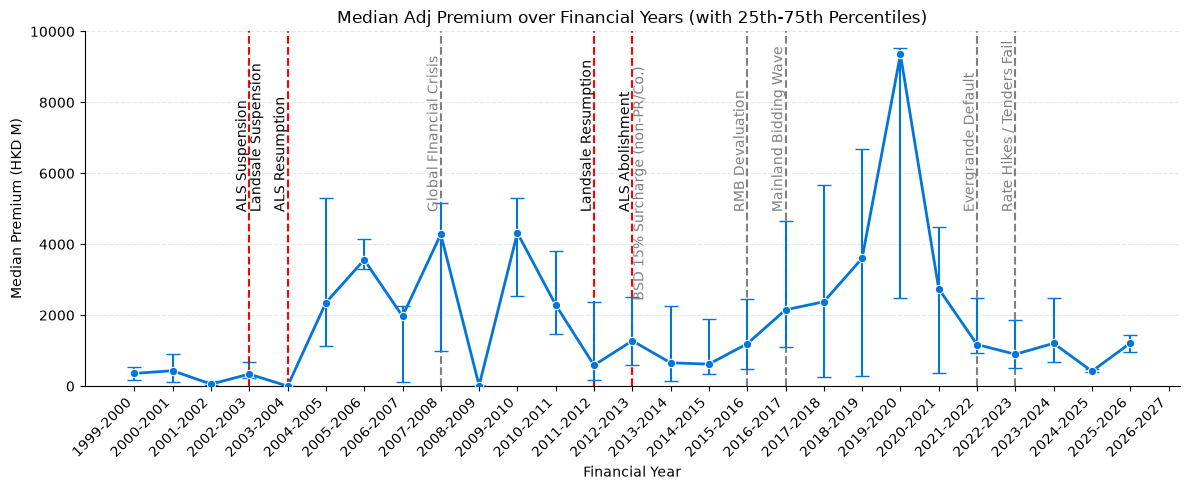

In [42]:
fig, ax = plt.subplots(figsize = (12,5))

sns.lineplot(data=res, x='financial_year', y='50%', marker='o', color='#0275d8', linewidth=2, ax= ax, zorder = 3)
plt.errorbar(
    x=res['financial_year'], 
    y=res['50%'], 
    yerr=[res['50%'] - res['25%'], res['75%'] - res['50%']], 
    fmt='none', color='#0275d8', capsize=5, elinewidth=1.5
    )
plt.title("Median Adj Premium over Financial Years (with 25th-75th Percentiles)")
plt.xlabel("Financial Year")
plt.ylabel("Median Premium (HKD M)")
plt.xticks(rotation=45, ha = 'right')
plt.ylim(bottom=0)
plt.grid(axis="y", linestyle = "--", zorder = 0, alpha = 0.3)
sns.despine()

ax.axvline(x = "2002-2003", linestyle = "--", color = "red")
ax.annotate("ALS Suspension", xy= ("2002-2003", 5000), ha = 'right', rotation = 90, zorder = 1)
ax.annotate("Landsale Suspension", xy= ("2002-2003", 5000), ha = 'left', rotation = 90)

ax.axvline(x = "2003-2004", linestyle = "--", color = "red", zorder = 1)
ax.annotate("ALS Resumption", xy= ("2003-2004", 5000), ha = 'right', rotation = 90)

ax.axvline(x = "2011-2012", linestyle = "--", color = "red", zorder = 1)
ax.annotate("Landsale Resumption", xy= ("2011-2012", 5000), ha = 'right', rotation = 90)

ax.axvline(x = "2012-2013", linestyle = "--", color = "red", zorder = 1)
ax.annotate("ALS Abolishment", xy= ("2012-2013", 5000), ha = 'right', rotation = 90)

ax.axvline(x = "2007-2008", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("Global FInancial Crisis", xy= ("2007-2008", 5000), ha = 'right', rotation = 90, color = 'grey')

ax.annotate("BSD 15% Surcharge (non-PR/Co.)", xy= ("2012-2013", 2500), ha = 'left', rotation = 90, color = 'gray')

ax.axvline(x = "2015-2016", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("RMB Devaluation", xy= ("2015-2016", 5000), ha = 'right', rotation = 90, color = 'gray')

ax.axvline(x = "2016-2017", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("Mainland Bidding Wave", xy= ("2016-2017", 5000), ha = 'right', rotation = 90, color = 'gray')

ax.axvline(x = "2021-2022", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("Evergrande Default", xy= ("2021-2022", 5000), ha = 'right', rotation = 90, color = 'gray')

ax.axvline(x = "2022-2023", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("Rate Hikes / Tenders Fail", xy= ("2022-2023", 5000), ha = 'right', rotation = 90, color = 'gray')

plt.tight_layout()
plt.show()

##### New Variable Adjusted Premium Per Site Area

In [43]:
print('Number of Obervations with missing site area data: ',filtered['site_area_sqm'].isna().sum())

Number of Obervations with missing site area data:  9


In [44]:
filtered['adj_premium_per_sqm'] = filtered['adj_premium_hkd_m'] * 1_000_000 / filtered['site_area_sqm']
print('Number of NA values in new variable: ', filtered['adj_premium_per_sqm'].isna().sum())

Number of NA values in new variable:  13


In [45]:
# Data Check

check = filtered[['award_date', 'premium_hkd_m', 'site_area_sqm', 'adj_premium_hkd_m', 'adj_premium_per_sqm']].copy()


print("NA counts:")
print(check.isna().sum())

print("\nRows where adj_premium_per_sqm is NA:")
problem_rows = filtered[
    filtered['adj_premium_per_sqm'].isna() != (filtered['site_area_sqm'].isna() | filtered['premium_hkd_m'].isna())
]
problem_rows[['award_date', 'premium_hkd_m', 'site_area_sqm', 'adj_premium_hkd_m', 'adj_premium_per_sqm']]

NA counts:
award_date              0
premium_hkd_m           9
site_area_sqm           9
adj_premium_hkd_m      13
adj_premium_per_sqm    13
dtype: int64

Rows where adj_premium_per_sqm is NA:


,award_date,premium_hkd_m,site_area_sqm,adj_premium_hkd_m,adj_premium_per_sqm
311,2026-07-01,1610.000,3830.0,NaN,NaN
312,2026-10-02,1806.880,3132.0,NaN,NaN
313,2026-02-16,1383.899,1349.2,NaN,NaN
314,2026-05-19,1627.000,14152.0,NaN,NaN


In [46]:
tmp = filtered[['award_date', 'premium_hkd_m']].copy()
tmp['Year'] = tmp['award_date'].dt.year

tmp = tmp.merge(hk_cpi[['Year', 'CPI', 'Deflator']], on='Year', how='left')

print("Missing Year:", tmp['Year'].isna().sum())
print("Missing CPI after merge:", tmp['CPI'].isna().sum())
print("Missing Deflator after merge:", tmp['Deflator'].isna().sum())

Missing Year: 0
Missing CPI after merge: 4
Missing Deflator after merge: 4


The reason for these missing values are because there is no CPI value for 2026

#### Variable: Adjusted Premium Per Square Meter

##### Distribution per Financial Year

In [47]:
res = filtered.groupby('financial_year')[['adj_premium_per_sqm']].describe().reset_index()
res.columns = res.columns.droplevel(0)
res = res.rename(columns={'': 'financial_year'})  

new_row_data = {col: 0 if col != 'financial_year' else '2003-2004' for col in res.columns}
new_row = pd.DataFrame([new_row_data])
res = pd.concat([res, new_row], ignore_index=True)
res = res.sort_values(by='financial_year').reset_index(drop=True)

res

,financial_year,count,mean,std,min,25%,50%,75%,max
0,1999-2000,22.0,69723.442007,69168.773866,2121.886893,17698.060524,46148.316591,105000.606157,2.375991e+05
1,2000-2001,18.0,76524.145669,67518.190407,4221.462134,19347.673038,64951.563349,112850.743566,2.077036e+05
2,2001-2002,10.0,29967.498690,31573.317207,5126.271313,10987.564399,18024.696671,34208.202738,1.115325e+05
3,2002-2003,7.0,107173.906491,80249.057393,29381.176833,39878.679545,90089.590194,154520.698195,2.419478e+05
4,2003-2004,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
5,2004-2005,5.0,319373.482847,200967.663945,91669.191280,168038.682636,323022.261086,416712.996953,5.974243e+05
6,2005-2006,3.0,433951.044940,93033.091361,326741.842236,404199.327802,481656.813368,487555.646292,4.934545e+05
7,2006-2007,9.0,169172.652230,122356.266827,9974.666984,27954.383644,215796.599916,225798.080858,3.489221e+05
8,2007-2008,8.0,354264.962286,323032.444570,31183.963249,63686.488704,335084.464079,527307.136199,9.569841e+05
9,2008-2009,1.0,88694.498503,NaN,88694.498503,88694.498503,88694.498503,88694.498503,8.869450e+04


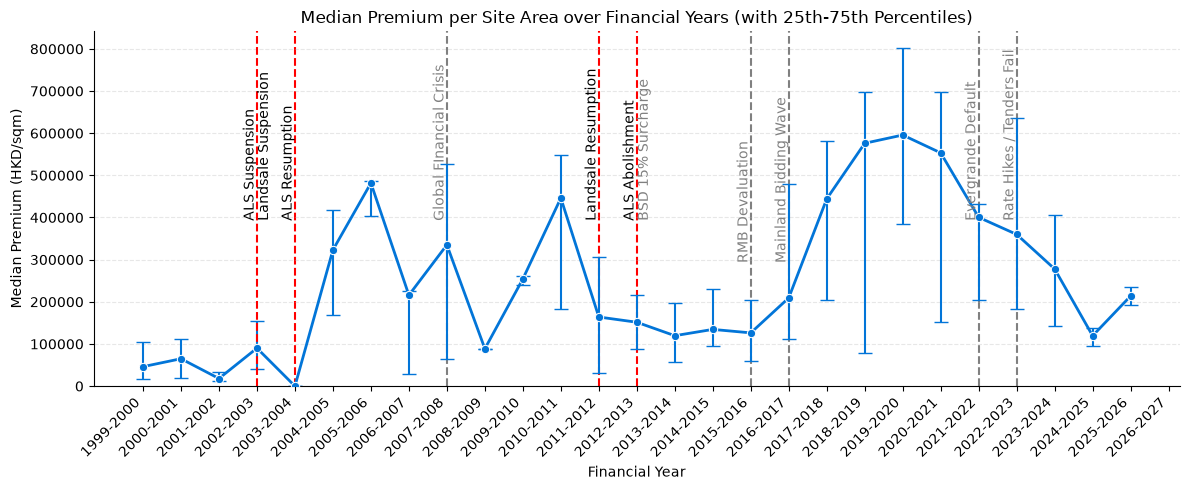

In [48]:
fig, ax = plt.subplots(figsize = (12,5))

sns.lineplot(data=res, x='financial_year', y='50%', marker='o', color='#0275d8', linewidth=2, ax= ax, zorder = 3)
plt.errorbar(
    x=res['financial_year'], 
    y=res['50%'], 
    yerr=[res['50%'] - res['25%'], res['75%'] - res['50%']], 
    fmt='none', color='#0275d8', capsize=5, elinewidth=1.5
    )
plt.title("Median Premium per Site Area over Financial Years (with 25th-75th Percentiles)")
plt.xlabel("Financial Year")
plt.ylabel("Median Premium (HKD/sqm)")
plt.ylim(bottom=0)
plt.xticks(rotation=45, ha = 'right')
plt.grid(axis="y", linestyle = "--", zorder = 0, alpha = 0.3)
sns.despine()

ax.axvline(x = "2002-2003", linestyle = "--", color = "red")
ax.annotate("ALS Suspension", xy=("2002-2003", 400000), ha = 'right', rotation = 90, zorder = 1)
ax.annotate("Landsale Suspension", xy=("2002-2003", 400000), ha = 'left', rotation = 90)

ax.axvline(x = "2003-2004", linestyle = "--", color = "red", zorder = 1)
ax.annotate("ALS Resumption", xy=("2003-2004", 400000), ha = 'right', rotation = 90)

ax.axvline(x = "2011-2012", linestyle = "--", color = "red", zorder = 1)
ax.annotate("Landsale Resumption", xy=("2011-2012", 400000), ha = 'right', rotation = 90)

ax.axvline(x = "2012-2013", linestyle = "--", color = "red", zorder = 1)
ax.annotate("ALS Abolishment", xy=("2012-2013", 400000), ha = 'right', rotation = 90)

ax.axvline(x = "2007-2008", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("Global FInancial Crisis", xy=("2007-2008", 400000), ha = 'right', rotation = 90, color = 'grey')

ax.annotate("BSD 15% Surcharge", xy=("2012-2013", 400000), ha = 'left', rotation = 90, color = 'gray')

ax.axvline(x = "2015-2016", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("RMB Devaluation", xy=("2015-2016", 300000), ha = 'right', rotation = 90, color = 'gray')

ax.axvline(x = "2016-2017", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("Mainland Bidding Wave", xy=("2016-2017", 300000), ha = 'right', rotation = 90, color = 'gray')

ax.axvline(x = "2021-2022", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("Evergrande Default", xy=("2021-2022", 400000), ha = 'right', rotation = 90, color = 'gray')

ax.axvline(x = "2022-2023", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("Rate Hikes / Tenders Fail", xy=("2022-2023", 400000), ha = 'right', rotation = 90, color = 'gray')

plt.tight_layout()
plt.show()

##### Group Over Sales Regime

In [49]:
# 1. Define the complete chronological list of years (ensure '2003-2004' is included)
year_order = sorted(total['financial_year'].unique())
if '2003-2004' not in year_order:
    year_order.append('2003-2004')
year_order = sorted(year_order) # Re-sort to put 2003-2004 in its chronological spot

# 2. Make the column categorical in your FILTERED dataframe BEFORE grouping
filtered['financial_year'] = pd.Categorical(filtered['financial_year'], categories=year_order, ordered=True)

# 3. Group with observed=False to automatically force empty combinations to appear
res = filtered.groupby(['sale_regime', 'financial_year'], observed=False)['adj_premium_per_sqm'].describe().reset_index()

# 4. Fill the empty generated rows (like 2003-2004) with 0 instead of NaN
stat_cols = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
res[stat_cols] = res[stat_cols].fillna(0)

res


,sale_regime,financial_year,count,mean,std,min,25%,50%,75%,max
0,ALS,1999-2000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
1,ALS,2000-2001,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
2,ALS,2001-2002,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
3,ALS,2002-2003,2.0,106955.344663,91322.128199,42380.848541,74668.096602,106955.344663,139242.592724,1.715298e+05
4,ALS,2003-2004,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
5,ALS,2004-2005,5.0,319373.482847,200967.663945,91669.191280,168038.682636,323022.261086,416712.996953,5.974243e+05
6,ALS,2005-2006,3.0,433951.044940,93033.091361,326741.842236,404199.327802,481656.813368,487555.646292,4.934545e+05
7,ALS,2006-2007,9.0,169172.652230,122356.266827,9974.666984,27954.383644,215796.599916,225798.080858,3.489221e+05
8,ALS,2007-2008,8.0,354264.962286,323032.444570,31183.963249,63686.488704,335084.464079,527307.136199,9.569841e+05
9,ALS,2008-2009,1.0,88694.498503,0.000000,88694.498503,88694.498503,88694.498503,88694.498503,8.869450e+04


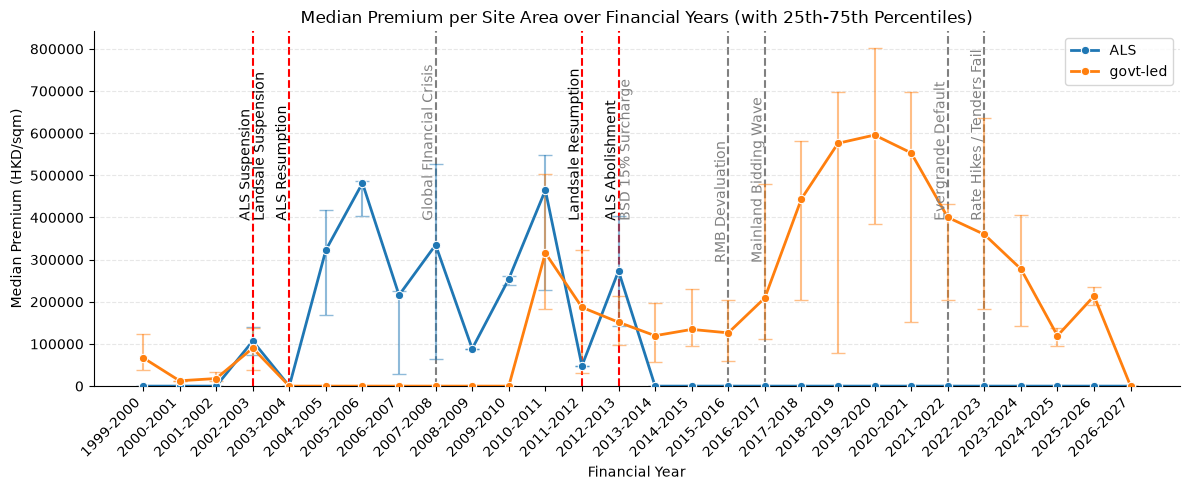

In [50]:
fig, ax = plt.subplots(figsize = (12,5))

palette = sns.color_palette("tab10", n_colors=res['sale_regime'].nunique())
regimes = res['sale_regime'].unique()

for i, regime in enumerate(regimes):
    sub = res[res['sale_regime'] == regime]
    color = palette[i]
    
    sns.lineplot(
        data=sub, x='financial_year', y='50%', 
        marker='o', linewidth=2, color=color, ax=ax, zorder=3, label=regime
    )
    
    ax.errorbar(
        x=sub['financial_year'], 
        y=sub['50%'], 
        yerr=[sub['50%'] - sub['25%'], sub['75%'] - sub['50%']], 
        fmt='none', color=color, capsize=5, elinewidth=1.5, zorder=2, alpha = 0.5
    )
plt.title("Median Premium per Site Area over Financial Years (with 25th-75th Percentiles)")
plt.xlabel("Financial Year")
plt.ylabel("Median Premium (HKD/sqm)")
plt.ylim(bottom=0)
plt.xticks(rotation=45, ha = 'right')
plt.grid(axis="y", linestyle = "--", zorder = 0, alpha = 0.3)
sns.despine()

ax.axvline(x = "2002-2003", linestyle = "--", color = "red")
ax.annotate("ALS Suspension", xy=("2002-2003", 400000), ha = 'right', rotation = 90, zorder = 1)
ax.annotate("Landsale Suspension", xy=("2002-2003", 400000), ha = 'left', rotation = 90)

ax.axvline(x = "2003-2004", linestyle = "--", color = "red", zorder = 1)
ax.annotate("ALS Resumption", xy=("2003-2004", 400000), ha = 'right', rotation = 90)

ax.axvline(x = "2011-2012", linestyle = "--", color = "red", zorder = 1)
ax.annotate("Landsale Resumption", xy=("2011-2012", 400000), ha = 'right', rotation = 90)

ax.axvline(x = "2012-2013", linestyle = "--", color = "red", zorder = 1)
ax.annotate("ALS Abolishment", xy=("2012-2013", 400000), ha = 'right', rotation = 90)

ax.axvline(x = "2007-2008", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("Global FInancial Crisis", xy=("2007-2008", 400000), ha = 'right', rotation = 90, color = 'grey')

ax.annotate("BSD 15% Surcharge", xy=("2012-2013", 400000), ha = 'left', rotation = 90, color = 'gray')

ax.axvline(x = "2015-2016", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("RMB Devaluation", xy=("2015-2016", 300000), ha = 'right', rotation = 90, color = 'gray')

ax.axvline(x = "2016-2017", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("Mainland Bidding Wave", xy=("2016-2017", 300000), ha = 'right', rotation = 90, color = 'gray')

ax.axvline(x = "2021-2022", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("Evergrande Default", xy=("2021-2022", 400000), ha = 'right', rotation = 90, color = 'gray')

ax.axvline(x = "2022-2023", linestyle = "--", color = "gray", zorder = 1)
ax.annotate("Rate Hikes / Tenders Fail", xy=("2022-2023", 400000), ha = 'right', rotation = 90, color = 'gray')

plt.tight_layout()
plt.show()

#### Location Factor

In [51]:
import geopandas as gpd

gdf = gpd.read_file("../data/hongkong_districts.gpkg")

In [52]:
import json
import plotly.express as px
from shapely.geometry.polygon import orient
from shapely.geometry import MultiPolygon

# Ensure WGS84 for Plotly
gdf_plot = gdf.to_crs(epsg=4326)

# Plotly's geo renderer expects exterior rings clockwise, opposite the GeoJSON
# RFC convention. Districts with many disjoint parts (e.g. Islands) render
# inverted (fill everywhere except the polygon) unless rings are flipped.
def fix_winding(geom):
    if geom.geom_type == 'Polygon':
        return orient(geom, sign=-1.0)
    elif geom.geom_type == 'MultiPolygon':
        return MultiPolygon([orient(p, sign=-1.0) for p in geom.geoms])
    return geom

gdf_plot['geometry'] = gdf_plot['geometry'].apply(fix_winding)

# Build GeoJSON
geojson = json.loads(gdf_plot.to_json())

# fig = px.choropleth(
#     gdf_plot,
#     geojson=geojson,
#     locations="ENAME",
#     featureidkey="properties.ENAME",
#     color="ENAME",          # replace with a real numeric column if needed
#     hover_name="ENAME",
#     projection="mercator"
# )

# fig.update_geos(fitbounds="locations", visible=False)
# fig.update_layout(
#     title="Map of Hong Kong Districts",
#     width=1000, height=700, margin=dict(l=0, r=0, t=60, b=0)
# )
# fig.show()

#### Median Price per Square Meter by District over Financial Years

In [53]:
import geopandas as gpd
from shapely.geometry import Point

# Tag each land sale with a district via a spatial join on its lat/long
geo_filtered = filtered.dropna(subset=['latitude', 'longitude']).copy()
geo_filtered['geometry'] = [Point(xy) for xy in zip(geo_filtered['longitude'], geo_filtered['latitude'])]
geo_filtered = gpd.GeoDataFrame(geo_filtered, geometry='geometry', crs='EPSG:4326')

joined = gpd.sjoin(geo_filtered, gdf_plot[['ENAME', 'geometry']], how='left', predicate='within')
joined = joined[~joined.index.duplicated(keep='first')]

filtered['district'] = None
filtered.loc[geo_filtered.index, 'district'] = joined['ENAME'].values
print('Rows without a matched district:', filtered['district'].isna().sum(), '/', filtered.shape[0])


Rows without a matched district: 29 / 315


In [54]:
(filtered['longitude'].isna() | filtered['latitude'].isna()).sum()

np.int64(29)

District matching failed because of lack of longitude or latitude entry in observation

In [55]:
district_median = (
    filtered.dropna(subset=['district', 'adj_premium_per_sqm'])
    .groupby(['district', 'financial_year'])
    .agg(adj_premium_per_sqm=('adj_premium_per_sqm', 'median'), n_sites=('adj_premium_per_sqm', 'count'))
    .reset_index()
)
year_order = sorted(district_median['financial_year'].unique())

# fig = px.line(
#     district_median,
#     x='financial_year',
#     y='adj_premium_per_sqm',
#     color='district',
#     markers=True,
#     category_orders={'financial_year': year_order}
# )

# fig.update_layout(
#     title='Median Price per Square Meter by District over Financial Years',
#     width=1000, height=500, margin=dict(l=0, r=0, t=60, b=0),
#     xaxis_title='Financial Year',
#     yaxis_title='Median Adjusted Premium per Square Meter (HKD)'
# )
# fig.show()

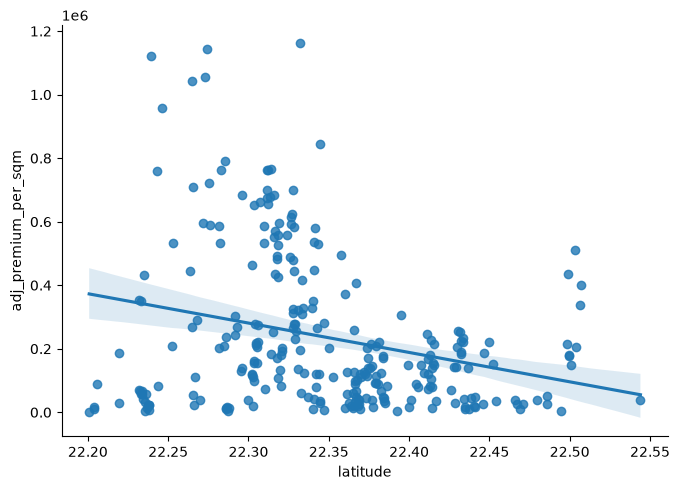

In [56]:
clean_spatial = filtered.dropna(subset=['adj_premium_per_sqm','latitude', 'longitude']).copy()

sns.lmplot(clean_spatial, x="latitude", y="adj_premium_per_sqm",height= 5, aspect= 1.38)

plt.tight_layout()
plt.show()

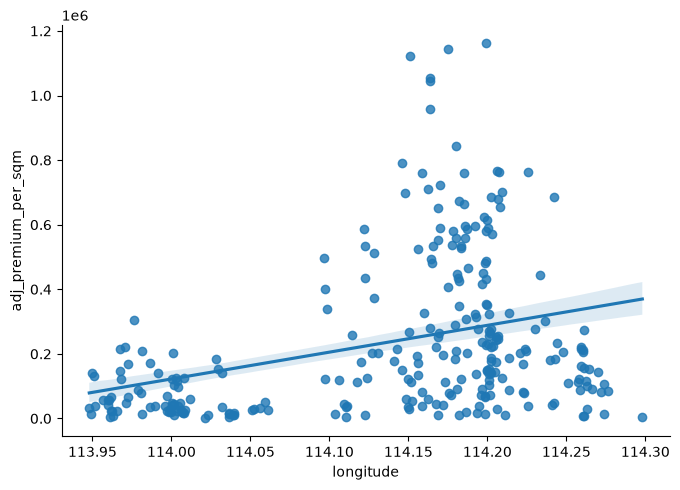

In [57]:
sns.lmplot(clean_spatial, x= "longitude", y = "adj_premium_per_sqm", height = 5, aspect = 1.38)

plt.tight_layout()
plt.show()

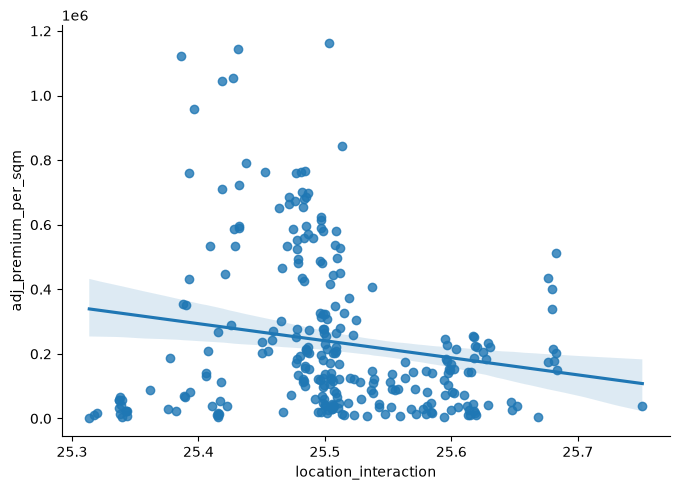

In [58]:
clean_spatial['location_interaction'] = clean_spatial['latitude']*clean_spatial['longitude'] / 100

sns.lmplot(clean_spatial, x="location_interaction", y = "adj_premium_per_sqm", height= 5, aspect = 1.38)

plt.tight_layout()
plt.show()

#### Animated Choropleth: Median Price per Square Meter by District over Financial Years

In [59]:
# import plotly.graph_objects as go

# all_districts = sorted(gdf_plot['ENAME'].unique())
# year_order = sorted(filtered['financial_year'].unique())

# # Sequential single-hue (blue) ramp, light -> dark, per the dataviz palette
# blue_scale = [
#     (0/12, '#cde2fb'), (1/12, '#b7d3f6'), (2/12, '#9ec5f4'), (3/12, '#86b6ef'),
#     (4/12, '#6da7ec'), (5/12, '#5598e7'), (6/12, '#3987e5'), (7/12, '#2a78d6'),
#     (8/12, '#256abf'), (9/12, '#1c5cab'), (10/12, '#184f95'), (11/12, '#104281'), (12/12, '#0d366b'),
# ]

# # Number of districts with a recorded median varies a lot by year (2 to 13 of
# # 18), so a single data-driven trace makes Hong Kong's visible shape appear to
# # change between frames -- districts with no sale that year simply don't get
# # drawn. Fix: a static grey base trace (all 18 districts, always drawn, never
# # animated) underneath a data-driven overlay trace (only districts with a
# # value that year, animated). The outline stays constant; only the fill
# # varies per frame.
# base_trace = go.Choropleth(
#     geojson=geojson, locations=all_districts, z=[0] * len(all_districts),
#     featureidkey='properties.ENAME',
#     colorscale=[[0, '#e1e0d9'], [1, '#e1e0d9']],
#     showscale=False, marker_line_color='#898781', marker_line_width=0.6,
#     hoverinfo='skip',
# )

# # Cap the color range at the 97th percentile: one outlier (Central & Western,
# # 2017-2018, ~6.3M) would otherwise wash out every other district/year. Values
# # above the cap still render (as the darkest step); hover shows the real value.
# first_year_data = district_median[district_median['financial_year'] == year_order[0]]
# overlay_trace = go.Choropleth(
#     geojson=geojson, locations=first_year_data['district'], z=first_year_data['adj_premium_per_sqm'],
#     featureidkey='properties.ENAME',
#     colorscale=blue_scale, zmin=0, zmax=1000000,
#     marker_line_color='#898781', marker_line_width=0.6,
#     colorbar=dict(title=dict(text='Median Premium<br>/sqm (HKD)', font=dict(size=11))),
#     customdata=first_year_data[['n_sites']],
#     hovertemplate='%{location}<br>Median Premium/sqm: %{z:.0f}<br>Sites Sold: %{customdata[0]}<extra></extra>',
# )

# frames = []
# for yr in year_order:
#     d = district_median[district_median['financial_year'] == yr]
#     frames.append(go.Frame(
#         data=[go.Choropleth(
#             locations=d['district'], z=d['adj_premium_per_sqm'], geojson=geojson,
#             featureidkey='properties.ENAME', colorscale=blue_scale, zmin=0, zmax=1000000,
#             marker_line_color='#898781', marker_line_width=0.6,
#             customdata=d[['n_sites']],
#             hovertemplate='%{location}<br>Median Premium/sqm: %{z:.0f}<br>Sites Sold: %{customdata[0]}<extra></extra>',
#         )],
#         name=yr,
#         traces=[1],  # update only the overlay trace, leave the grey base alone
#     ))

# fig = go.Figure(data=[base_trace, overlay_trace], frames=frames)
# fig.update_geos(fitbounds='locations', visible=False)
# fig.update_layout(
#     title='Median Price per Square Meter by District over Financial Years',
#     width=1000, height=700, margin=dict(l=0, r=0, t=60, b=140),
#     sliders=[dict(
#         active=0,
#         steps=[
#             dict(method='animate', label=yr,
#                  args=[[yr], dict(mode='immediate', frame=dict(duration=0, redraw=True))])
#             for yr in year_order
#         ],
#     )],
#     updatemenus=[dict(
#         type='buttons', showactive=False,
#         buttons=[dict(label='Play', method='animate',
#                        args=[None, dict(frame=dict(duration=500, redraw=True), fromcurrent=True)])],
#     )],
# )
# fig.show()

#### Variable: Number of Bids

##### Total Number of Bids over Financial Years

In [60]:
filtered['num_bids'] = pd.to_numeric(filtered['num_bids'], errors="coerce")
# Rows with no successful_tenderer are pending/unawarded tenders (e.g. two
# FY2026-27 sites scheduled but not yet awarded) -- not completed sales, so
# they're excluded from bid/tenderer stats entirely.
awarded = filtered[filtered['successful_tenderer'].notna()].copy()

# A site that sold had at least one bid -- the winning tender itself -- even
# when the actual count wasn't recorded ('N.A.', '---------'). Flooring
# unrecorded rows at 1 (rather than leaving them NaN, which pandas' .sum()
# silently turns into 0) guarantees the yearly total is never less than the
# number of sites sold that year, e.g. FY2006-07: 11 sites sold, none with a
# recorded bid count -> num_bids floors to 11, not 0.
bids_by_fy = awarded.assign(num_bids=awarded['num_bids']).groupby("financial_year")[['num_bids']].sum().reset_index()
bids_by_fy

,financial_year,num_bids
0,1999-2000,43.0
1,2000-2001,35.0
2,2001-2002,0.0
3,2002-2003,0.0
4,2004-2005,0.0
5,2005-2006,0.0
6,2006-2007,0.0
7,2007-2008,0.0
8,2008-2009,0.0
9,2009-2010,0.0


Data check: For FY06/07 and FY02/03 all entries in num_bids are NaN. Fix: num_bids is at least the number of sites sold in the Financial Year

#### Extract Parent Developer from Bracketed Tenderer Names

In [61]:
import re

# Some successful_tenderer values embed the parent developer in a trailing
# "(...)", e.g. "Apex Speed Ltd. (Sino Land Co. Ltd.)". Handles one level of
# nested parens (e.g. "Cheung Kong (Holdings) Ltd.") and normalizes multi-party
# joint ventures ("and", ",", "<br/>") to the " / " separator already used
# elsewhere in parent_developer. Only fills rows where parent_developer is NaN --
# existing curated values are left untouched.
PAREN_RE = re.compile(r'\(((?:[^()]|\([^()]*\))*)\)\s*$')

def extract_parent(name):
    if pd.isna(name):
        return None
    m = PAREN_RE.search(str(name).strip())
    if not m:
        return None
    s = m.group(1).strip().replace('<br/>', ' ').replace('<br>', ' ')
    s = re.sub(r'\s+and\s+', ' / ', s)
    s = re.sub(r'\s*/\s*', ' / ', s)
    s = re.sub(r'\s*,\s*', ' / ', s)
    return re.sub(r'\s+', ' ', s).strip()

extracted = filtered['successful_tenderer'].apply(extract_parent)
fillable = filtered['parent_developer'].isna() & extracted.notna()
print('Rows filled from bracketed tenderer names:', fillable.sum())
filtered.loc[fillable, 'parent_developer'] = extracted[fillable]

# Remaining brackets belong to the tenderer's own legal name (e.g. "Sinopec
# (Hong Kong) Limited") with no parent stated in that row -- can't be resolved
# by regex and are left as NaN for manual review.
unresolved = filtered[filtered['parent_developer'].isna() & total['successful_tenderer'].str.contains(r'\(', na=False)]
print('Unresolved distinct tenderer names:', unresolved['successful_tenderer'].nunique())
#pd.DataFrame(unresolved['successful_tenderer'].unique(), columns=['successful_tenderer'])

Rows filled from bracketed tenderer names: 16
Unresolved distinct tenderer names: 36


/var/folders/yp/wyztsj9s75l9q9cwvlpcq7qw0000gn/T/ipykernel_48245/1948714475.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.


In [62]:
awarded['Tenderer'] = np.where(awarded['parent_developer'].notna(), 
                                awarded['parent_developer'], awarded['successful_tenderer'])
bids_by_fy['n_tenderers'] = awarded.groupby("financial_year")[['Tenderer']].nunique().reset_index()['Tenderer']
bids_by_fy

,financial_year,num_bids,n_tenderers
0,1999-2000,43.0,22
1,2000-2001,35.0,18
2,2001-2002,0.0,10
3,2002-2003,0.0,7
4,2004-2005,0.0,5
5,2005-2006,0.0,3
6,2006-2007,0.0,9
7,2007-2008,0.0,8
8,2008-2009,0.0,1
9,2009-2010,0.0,4


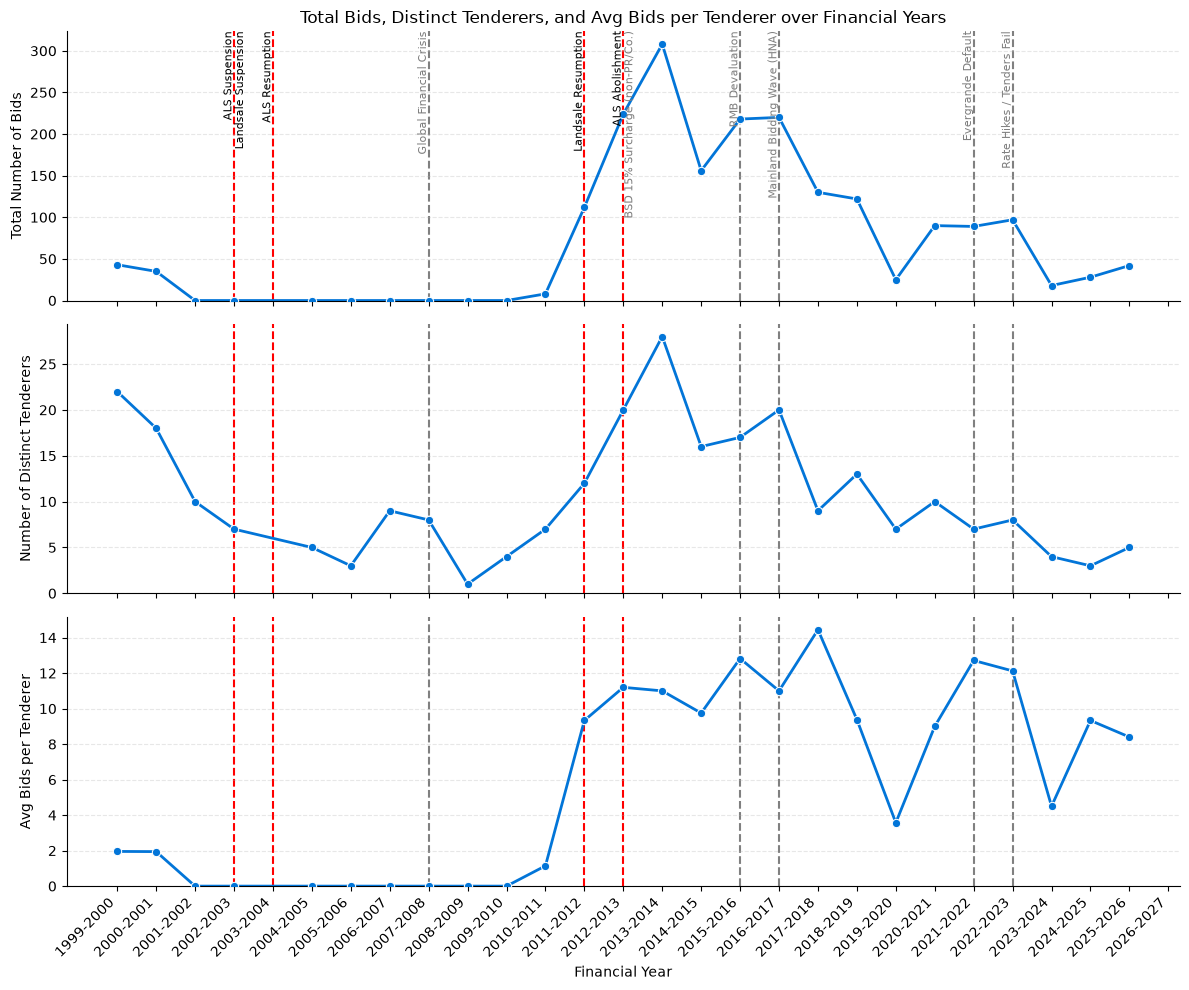

In [63]:
bids_by_fy['avg_bids_per_tenderer'] = bids_by_fy['num_bids'] / bids_by_fy['n_tenderers']

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

sns.lineplot(data=bids_by_fy, x='financial_year', y='num_bids', marker='o', color='#0275d8', linewidth=2, ax=axes[0], zorder=3)
sns.lineplot(data=bids_by_fy, x='financial_year', y='n_tenderers', marker='o', color='#0275d8', linewidth=2, ax=axes[1], zorder=3)
sns.lineplot(data=bids_by_fy, x='financial_year', y='avg_bids_per_tenderer', marker='o', color='#0275d8', linewidth=2, ax=axes[2], zorder=3)

axes[0].set_title('Total Bids, Distinct Tenderers, and Avg Bids per Tenderer over Financial Years')
axes[0].set_ylabel('Total Number of Bids')
axes[1].set_ylabel('Number of Distinct Tenderers')
axes[2].set_ylabel('Avg Bids per Tenderer')
axes[2].set_xlabel('Financial Year')

policy_events = ['2002-2003', '2003-2004', '2011-2012', '2012-2013']
market_events = ['2007-2008', '2015-2016', '2016-2017', '2021-2022', '2022-2023']

for ax in axes:
    ax.set_ylim(bottom=0)
    ax.grid(axis='y', linestyle='--', zorder=0, alpha=0.3)
    for yr in policy_events:
        ax.axvline(x=yr, linestyle='--', color='red', zorder=1)
    for yr in market_events:
        ax.axvline(x=yr, linestyle='--', color='gray', zorder=1)

top = axes[0].get_ylim()[1]
axes[0].annotate('ALS Suspension', xy=('2002-2003', top), ha='right', va='top', rotation=90, fontsize=8)
axes[0].annotate('Landsale Suspension', xy=('2002-2003', top), ha='left', va='top', rotation=90, fontsize=8)
axes[0].annotate('ALS Resumption', xy=('2003-2004', top), ha='right', va='top', rotation=90, fontsize=8)
axes[0].annotate('Landsale Resumption', xy=('2011-2012', top), ha='right', va='top', rotation=90, fontsize=8)
axes[0].annotate('ALS Abolishment', xy=('2012-2013', top), ha='right', va='top', rotation=90, fontsize=8)
axes[0].annotate('BSD 15% Surcharge (non-PR/Co.)', xy=('2012-2013', top), ha='left', va='top', rotation=90, fontsize=8, color='gray')
axes[0].annotate('Global Financial Crisis', xy=('2007-2008', top), ha='right', va='top', rotation=90, fontsize=8, color='gray')
axes[0].annotate('RMB Devaluation', xy=('2015-2016', top), ha='right', va='top', rotation=90, fontsize=8, color='gray')
axes[0].annotate('Mainland Bidding Wave (HNA)', xy=('2016-2017', top), ha='right', va='top', rotation=90, fontsize=8, color='gray')
axes[0].annotate('Evergrande Default', xy=('2021-2022', top), ha='right', va='top', rotation=90, fontsize=8, color='gray')
axes[0].annotate('Rate Hikes / Tenders Fail', xy=('2022-2023', top), ha='right', va='top', rotation=90, fontsize=8, color='gray')

plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

In [64]:
filtered['Tenderer'] = np.where(filtered['parent_developer'].notna(), 
                                filtered['parent_developer'], filtered['successful_tenderer'])

#filtered[filtered['financial_year'].between("2001-2002", "2009-2010")][['num_bids', 'in_als', 'sale_regime']]

Not a viable parameter anymore

### Variable: Buyer Type

In [65]:
print("# NaN:", filtered['buyer_type'].isna().sum())
print(filtered['buyer_type'].unique())
print(filtered['buyer_type'].value_counts())

# NaN: 115
<StringArray>
[nan, 'local_major', 'other', 'consortium', 'local_minor', 'mainland']
Length: 6, dtype: str
buyer_type
local_major    91
other          60
consortium     18
local_minor    17
mainland       14
Name: count, dtype: int64


In [66]:
pd.crosstab(
    filtered['district'],
    filtered['buyer_type']
).reset_index()

buyer_type,district,consortium,local_major,local_minor,mainland,other
0,CENTRAL & WESTERN,1,4,0,0,1
1,EASTERN,0,1,0,0,2
2,ISLANDS,0,8,0,0,7
3,KOWLOON CITY,5,18,1,5,6
4,KWAI TSING,0,0,1,1,2
5,KWUN TONG,0,2,0,1,2
6,NORTH,0,6,1,0,2
7,SAI KUNG,0,13,0,0,5
8,SHA TIN,1,11,1,1,4
9,SHAM SHUI PO,1,1,0,2,1


In [67]:
filtered.groupby('buyer_type')['site_area_sqm'].describe().reset_index()

,buyer_type,count,mean,std,min,25%,50%,75%,max
0,consortium,18.0,13895.094444,6531.551657,1901.7,9709.75,11983.0,19099.25,23500.0
1,local_major,90.0,12937.948889,13343.647256,271.3,4376.00,9704.0,16105.50,75500.0
2,local_minor,17.0,9612.658824,11224.191715,1057.8,1967.00,4340.0,8780.00,32900.0
3,mainland,14.0,11028.071429,10247.658318,3132.0,4379.50,7980.5,9873.75,37696.0
4,other,60.0,7823.561667,7510.098829,200.7,1739.75,5726.5,10348.50,28457.0


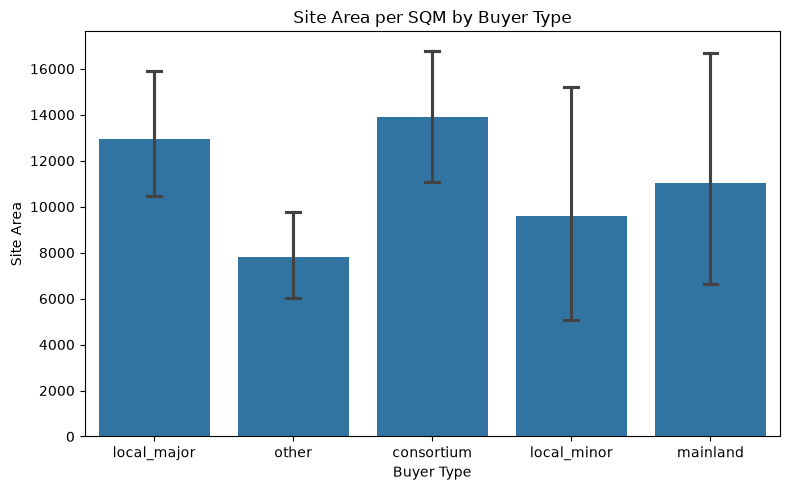

In [68]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=filtered, 
    x='buyer_type', 
    y='site_area_sqm', 
    errorbar=('ci', 95),    
    capsize=0.1
)

plt.title('Site Area per SQM by Buyer Type')
plt.xlabel('Buyer Type')
plt.ylabel('Site Area')
plt.tight_layout()
plt.show()

In [69]:
filtered.groupby('buyer_type')['adj_premium_per_sqm'].agg(
    ['count', 'mean', 'median', 'std']
).reset_index()

,buyer_type,count,mean,median,std
0,consortium,18,576829.430582,613762.814372,334922.205144
1,local_major,88,286423.582850,180584.254437,261647.912181
2,local_minor,17,222103.568085,115646.454778,220511.721591
3,mainland,13,307822.360042,255504.201867,192696.808235
4,other,60,241754.969420,145760.462601,230528.657631


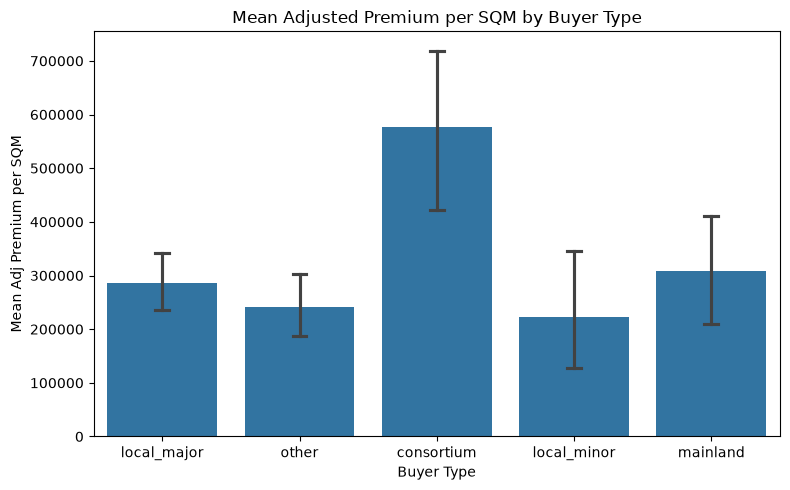

In [70]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=filtered, 
    x='buyer_type', 
    y='adj_premium_per_sqm', 
    errorbar=('ci', 95),    
    capsize=0.1
)

plt.title('Mean Adjusted Premium per SQM by Buyer Type')
plt.xlabel('Buyer Type')
plt.ylabel('Mean Adj Premium per SQM')
plt.tight_layout()
plt.show()

In [71]:
df_summary = pd.crosstab(filtered['buyer_type'], filtered['in_als']).reset_index()
df_summary.columns.name = None
df_summary = df_summary.melt(id_vars="buyer_type", var_name="in_als", value_name="count")
df_summary

,buyer_type,in_als,count
0,consortium,0,15
1,local_major,0,58
2,local_minor,0,15
3,mainland,0,12
4,other,0,36
5,consortium,1,3
6,local_major,1,33
7,local_minor,1,2
8,mainland,1,2
9,other,1,24


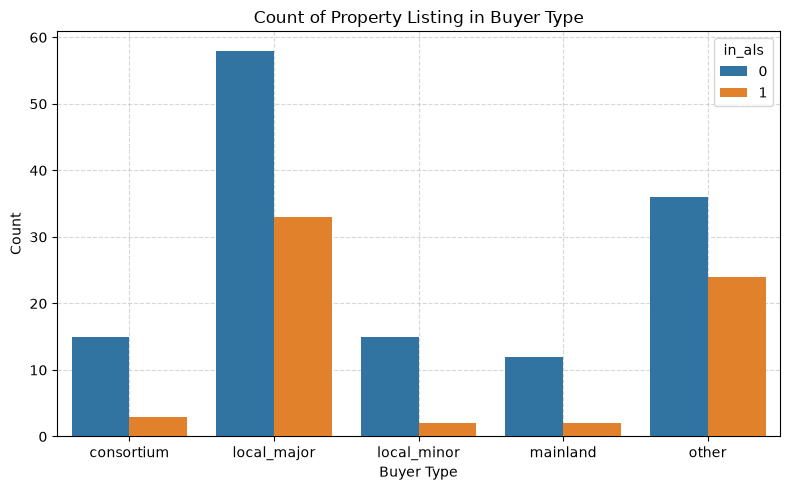

In [72]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_summary, 
    x='buyer_type', 
    y='count',
    hue= "in_als",  
    capsize=0.1,
    zorder = 3
)

plt.title('Count of Property Listing in Buyer Type')
plt.xlabel('Buyer Type')
plt.ylabel('Count')
plt.grid(True, zorder = 0, linestyle = "--", alpha = 0.5)
plt.tight_layout()
plt.show()

In [73]:
df_summary = pd.crosstab(filtered['buyer_type'], filtered['sale_regime']).reset_index()
df_summary.columns.name = None
df_summary = df_summary.melt(id_vars="buyer_type", var_name="sale_regime", value_name="count")
df_summary

,buyer_type,sale_regime,count
0,consortium,ALS,0
1,local_major,ALS,6
2,local_minor,ALS,0
3,mainland,ALS,0
4,other,ALS,3
5,consortium,govt-led,18
6,local_major,govt-led,85
7,local_minor,govt-led,17
8,mainland,govt-led,14
9,other,govt-led,57


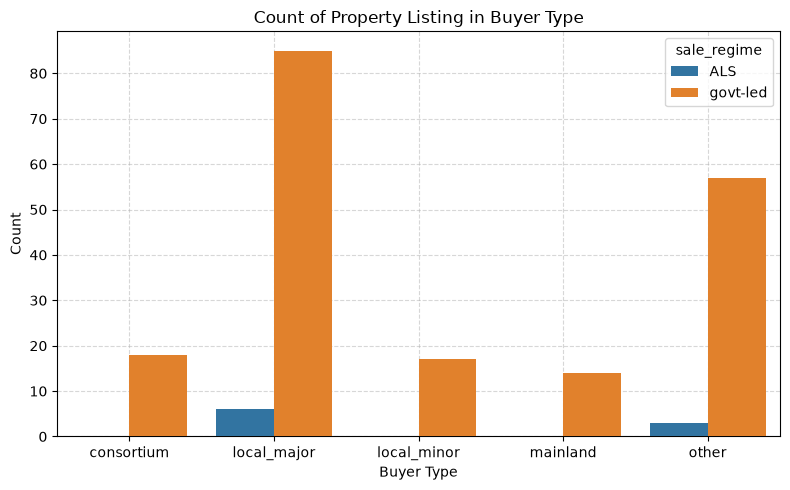

In [74]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_summary, 
    x='buyer_type', 
    y='count',
    hue= "sale_regime",  
    capsize=0.1,
    zorder = 3
)

plt.title('Count of Property Listing in Buyer Type')
plt.xlabel('Buyer Type')
plt.ylabel('Count')
plt.grid(True, zorder = 0, linestyle = "--", alpha = 0.5)
plt.tight_layout()
plt.show()

### Variable: US Interest Rate

In [75]:
fed = pd.read_csv("../data/FEDFUNDS.csv", header=0)
fed['observation_date'] = pd.to_datetime(fed['observation_date'])
print(fed.dtypes)
print(filtered['award_date'].dtype)

observation_date    datetime64[us]
FEDFUNDS                   float64
dtype: object
datetime64[us]


In [76]:
filtered = filtered.sort_values(by="award_date", ascending=True)
filtered = pd.merge_asof(left=filtered, right=fed, left_on="award_date", right_on="observation_date", direction="backward")
filtered[['award_date', 'observation_date', 'FEDFUNDS']].head()

,award_date,observation_date,FEDFUNDS
0,1999-04-08,1999-04-01,4.74
1,1999-04-08,1999-04-01,4.74
2,1999-04-08,1999-04-01,4.74
3,1999-04-08,1999-04-01,4.74
4,1999-04-20,1999-04-01,4.74


In [77]:
filtered = filtered.drop(columns={'observation_date'})

### Variable: Real GDP

In [78]:
rgdp = pd.read_csv("../data/Real_GDP.csv", header=2)
rgdp = (rgdp[rgdp['Country Name'] == "Hong Kong SAR, China"]
        .melt(id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'], var_name="Year", value_name="RGDP(Billions)")
        .drop(columns = {'Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'}))
rgdp["RGDP(Billions)"] = rgdp['RGDP(Billions)'] / 1000000000
rgdp['Year'] = pd.to_numeric(rgdp['Year'], errors= "coerce")
rgdp.head()

,Year,RGDP(Billions)
0,1960.0,NaN
1,1961.0,12.533003
2,1962.0,14.324077
3,1963.0,16.582033
4,1964.0,18.012713


In [79]:
filtered = filtered.merge(rgdp, on="Year", how="left")
filtered.columns

Index(['premium_hkd_m', 'num_bids', 'successful_tenderer', 'buyer_normalized',
       'buyer_type', 'use_category_normalized', 'latitude', 'longitude',
       'parent_developer', 'award_date', 'sale_regime', 'site_area_sqm',
       'lot_number', 'financial_year', 'location', 'max_gfa',
       'accommodation_value', 'lot_number_normalized', 'in_als', 'Lot Number',
       'Location', 'User', 'Site Area', 'Plot Ratio', 'Deposit (HK$ M)',
       'Estimated Earliest Site Available Date', 'Period', 'Rolled over',
       'als_site_area_sqm', 'Year', 'Deflator', 'adj_premium_hkd_m',
       'adj_premium_per_sqm', 'district', 'Tenderer', 'FEDFUNDS',
       'RGDP(Billions)'],
      dtype='str')

### Variable: max_gfa

In [80]:
filtered['max_gfa'].isna().sum()

np.int64(127)

In [81]:
filtered['max_gfa'].describe()

count    1.880000e+02
mean     8.316160e+04
std      1.952385e+05
min      5.752000e+02
25%      1.174950e+04
50%      3.295350e+04
75%      6.664525e+04
max      1.438200e+06
Name: max_gfa, dtype: float64

<Axes: title={'center': 'Distribution of max_gfa'}, xlabel='max_gfa', ylabel='Frequency'>

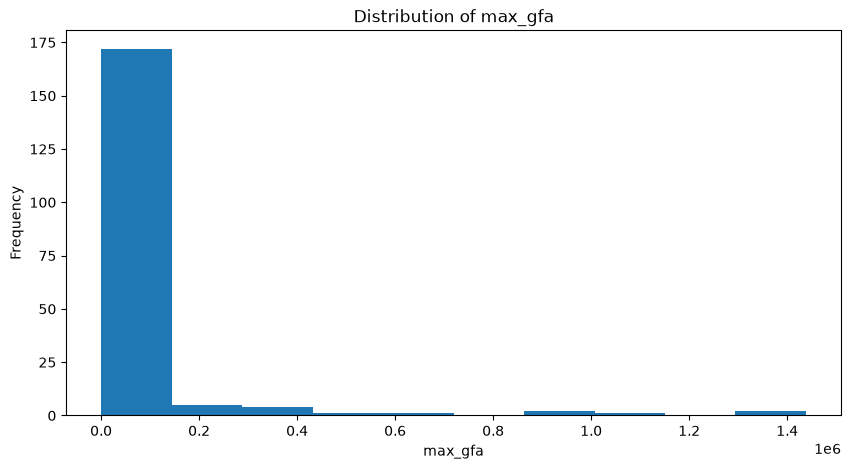

In [82]:
filtered['max_gfa'].plot(kind="hist", figsize = (10,5), xlabel="max_gfa", title = "Distribution of max_gfa")

### Variable: Accomodation Value

In [84]:
filtered['accommodation_value'].isna().count()

np.int64(315)

In [85]:
filtered['accommodation_value'].describe()

count      188.000000
mean     10000.760638
std       8880.287065
min       1444.000000
25%       4279.250000
50%       7069.500000
75%      12760.000000
max      62354.000000
Name: accommodation_value, dtype: float64

<Axes: title={'center': 'Distribution of Accomodation Value'}, xlabel='accomodation_value', ylabel='Frequency'>

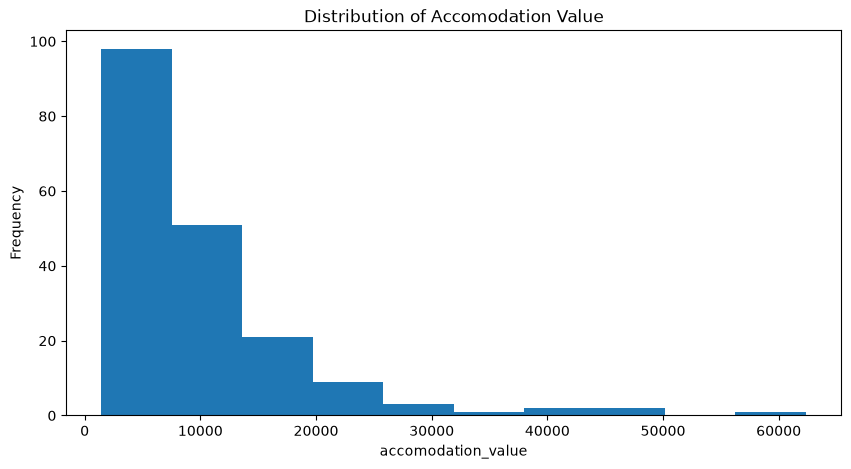

In [86]:
filtered['accommodation_value'].plot(kind= "hist", xlabel = "accomodation_value", title = "Distribution of Accomodation Value", figsize=(10,5))

## Regression Data Set

In [87]:
filtered = filtered.merge(bids_by_fy[['financial_year', 'n_tenderers']], on="financial_year", how="left")

In [88]:
filtered.columns

Index(['premium_hkd_m', 'num_bids', 'successful_tenderer', 'buyer_normalized',
       'buyer_type', 'use_category_normalized', 'latitude', 'longitude',
       'parent_developer', 'award_date', 'sale_regime', 'site_area_sqm',
       'lot_number', 'financial_year', 'location', 'max_gfa',
       'accommodation_value', 'lot_number_normalized', 'in_als', 'Lot Number',
       'Location', 'User', 'Site Area', 'Plot Ratio', 'Deposit (HK$ M)',
       'Estimated Earliest Site Available Date', 'Period', 'Rolled over',
       'als_site_area_sqm', 'Year', 'Deflator', 'adj_premium_hkd_m',
       'adj_premium_per_sqm', 'district', 'Tenderer', 'FEDFUNDS',
       'RGDP(Billions)', 'n_tenderers'],
      dtype='str')

In [90]:
vars = ['adj_premium_per_sqm', 'latitude', 'longitude', 'FEDFUNDS', 'RGDP(Billions)', 'in_als', 'sale_regime', 'max_gfa', 'n_tenderers', 'award_date', 'accommodation_value']
regression = filtered[vars]
regression.shape

(315, 11)

In [92]:
regression.dropna().to_csv("../data/regression.csv", index=False)